In [42]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math
import warnings
import re

## Configuration


### Path Configuration


In [43]:
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20251120_11-00-03").resolve()
TOPOLOGY_FOLDER_TO_ANALYZE = "random_20N"

### Log File Names


In [44]:
PDR_LOG_FILE = "log_PDR.csv"
LATENCY_LOG_FILE = "log_e2eLat.csv"
PARENT_CHG_LOG_FILE = "log_ParChg.csv"
APP_LOG_FILE = "log_app.csv"
PARAMETERS_FILE = "parameters.txt"

### Plot Style


In [45]:
# Time window size (in seconds) to aggregate parent changes
TIME_BIN_SIZE_S = 5.0

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

## Helpers Functions


In [46]:
def process_pdr_file(file_path):
    """Reads PDR file and returns the mean PDR of that run."""
    try:
        df = pd.read_csv(file_path, skipinitialspace=True)
        if df.empty or "delivered" not in df.columns:
            return None
        return df["delivered"].mean()
    except Exception:
        return None


def get_interarrivals(file_path):
    """Reads App Log file and returns the mean inter-arrival time."""
    df = pd.read_csv(file_path, skipinitialspace=True)
    df = df[df["event"] == "SEND"]
    df = df.sort_values(by="time")
    df["inter_arrival"] = df.groupby("node_id")["time"].diff().fillna(0)
    return df


def process_latency_file(file_path):
    """Reads Latency file and returns a list of latency values."""
    try:
        df = pd.read_csv(file_path, skipinitialspace=True)
        if df.empty or "latency" not in df.columns:
            return []
        return df["latency"].tolist()
    except Exception:
        return []


def get_simulation_parameters(file_path):
    """Reads Simulation Parameters file (.txt) and returns a dictionary of parameters."""
    regex = r"^(.*): (.*)$"  # Regex to match "Parameter: Value" lines
    params = {}
    try:
        with open(file_path, "r") as f:
            for line in f:
                match = re.match(regex, line.strip())
                if match:
                    key = match.group(1).strip()
                    value = match.group(2).strip()
                    params[key] = value
    except Exception:
        pass
    return params


def process_parent_change_files(file_paths, bin_size=1.0):
    """
    Aggregates parent change events over time across multiple runs.

    Returns:
        bin_centers (np.array): The time axis.
        mean_counts (np.array): Average parent changes per bin.
    """
    if not file_paths:
        return None, None

    all_histograms = []
    max_time = 0

    # First pass: Determine max simulation time to define bins common to all runs
    for fp in file_paths:
        try:
            df = pd.read_csv(fp, skipinitialspace=True)
            if not df.empty and "timestamp" in df.columns:
                local_max = df["timestamp"].max()
                if local_max > max_time:
                    max_time = local_max
        except Exception:
            continue

    if max_time == 0:
        return None, None

    # Define bins
    bins = np.arange(0, math.ceil(max_time) + bin_size, bin_size)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Second pass: Histogram the data for each run
    valid_runs = 0
    for fp in file_paths:
        try:
            df = pd.read_csv(fp, skipinitialspace=True)
            if df.empty or "timestamp" not in df.columns:
                continue

            # Count events in each time bin
            counts, _ = np.histogram(df["timestamp"], bins=bins)
            all_histograms.append(counts)
            valid_runs += 1
        except Exception:
            continue

    if valid_runs == 0:
        return None, None

    # Stack arrays: shape (num_runs, num_bins)
    data_matrix = np.vstack(all_histograms)

    # Calculate Statistics (ONLY MEAN, NO CI)
    mean_counts = np.mean(data_matrix, axis=0)

    return bin_centers, mean_counts

## Main Analysis Batch 20251120_11-00-03


In [47]:
analysis_base_path = PATH_TO_RESULTS_PARENT_FOLDER / TOPOLOGY_FOLDER_TO_ANALYZE

if not analysis_base_path.exists():
    print(f"CRITICAL ERROR: Path does not exist: {analysis_base_path}")
    sys.exit(1)

print(f"Analyizing Topology: {TOPOLOGY_FOLDER_TO_ANALYZE}")

# 1. Discover Configurations (subfolders)
configs = sorted([d for d in analysis_base_path.iterdir() if d.is_dir()])
if not configs:
    print("No configuration folders found.")
    sys.exit(0)

results = pd.DataFrame(
    columns=[
        "configuration",
        "seed",
        "pdr",
        "latency",
        "par_changes",
        "mean_interarrival",
        "true_mean_interarrival",
    ]
)

rows = []

# --- DATA COLLECTION PHASE ---
print("Collecting data from files...")
for config_dir in configs:
    config_name = config_dir.name
    print(f"  > Processing config: {config_name}")

    seed_dirs = sorted([d for d in config_dir.iterdir() if d.is_dir()])

    for seed in seed_dirs:
        repetition_data = {
            "configuration": config_name,
            "seed": seed.name,
            "mean_interarrival": get_interarrivals(seed / APP_LOG_FILE)[
                "inter_arrival"
            ].mean(),
            "true_mean_interarrival": float(
                get_simulation_parameters(seed / PARAMETERS_FILE)["mean_interarrival"]
            ),
        }

        # PDR
        p = process_pdr_file(seed / PDR_LOG_FILE)
        repetition_data["pdr"] = p

        # Latency
        l = process_latency_file(seed / LATENCY_LOG_FILE)
        repetition_data["latency"] = np.mean(l) if l else None

        # Parent Changes (Store path only, process later)
        pc_file = seed / PARENT_CHG_LOG_FILE
        repetition_data["par_changes"] = pc_file

        rows.append(repetition_data)

results = pd.DataFrame(rows)

Analyizing Topology: random_20N
  > Processing config: ideal
  > Processing config: lossy
  > Processing config: stable
  > Processing config: stable_high_pl
  > Processing config: stable_mid_pl
  > Processing config: unstable


In [48]:
results

,configuration,seed,mean_interarrival,true_mean_interarrival,pdr,latency,par_changes
0,ideal,12345,59.986209,60.0,0.923077,0.008637,/home/simone/uni/spe/SPE-project/results/batch...
1,ideal,12345_antithetic,54.289619,60.0,0.952381,0.008979,/home/simone/uni/spe/SPE-project/results/batch...
2,ideal,12346,53.066403,60.0,0.951827,0.009363,/home/simone/uni/spe/SPE-project/results/batch...
3,ideal,12346_antithetic,62.459145,60.0,0.924901,0.009357,/home/simone/uni/spe/SPE-project/results/batch...
4,ideal,12347,57.775183,60.0,0.920145,0.008405,/home/simone/uni/spe/SPE-project/results/batch...
...,...,...,...,...,...,...,...
595,unstable,12392_antithetic,67.231598,60.0,0.175824,0.009655,/home/simone/uni/spe/SPE-project/results/batch...
596,unstable,12393,42.943760,60.0,0.103448,0.017625,/home/simone/uni/spe/SPE-project/results/batch...
597,unstable,12393_antithetic,72.684595,60.0,0.182320,0.018606,/home/simone/uni/spe/SPE-project/results/batch...
598,unstable,12394,58.450991,60.0,0.350515,0.016621,/home/simone/uni/spe/SPE-project/results/batch...


In [49]:
# Y_mean = results.groupby("configuration")["pdr"].mean()
# X_mean = results.groupby("configuration")["mean_interarrival"].mean()

# cov_YX = results.groupby("configuration")[["pdr", "mean_interarrival"]].cov().iloc[0, 1]
# var_X = results.groupby("configuration")["mean_interarrival"].var()


# beta = cov_YX / var_X

# assert (
#     results.groupby("configuration")["true_mean_interarrival"].nunique() == 1
# ), "True mean inter-arrival times differ across runs!"
# mu_X = results["true_mean_interarrival"].loc[0]

# Y_cv = Y_mean - beta * (X_mean - mu_X)
# Y_cv, Y_mean

# !!!!!!!!!!!!!!! Previous code obsolete, it does not work with multiple configurations !!!!!!!!!!!!!!!

In [ ]:
H = 4  # number of strata

# TODO: Check again all this mess!!!

all_results = []
all_summaries = {}

# Verify the true mean is the same for all runs
assert (
    results["true_mean_interarrival"].nunique() == 1
), "true_mean_interarrival is not constant across runs"

true_mu = results["true_mean_interarrival"].iloc[0]

for cfg, df_cfg in results.groupby("configuration", observed=False):

    print(f"\n=== Processing configuration: {cfg} ===")

    df_cfg = df_cfg.copy()

    # ----------------------------------------------------------
    # 1. Compute theoretical quantiles for the distribution
    #    of the mean inter-arrival time
    # ----------------------------------------------------------
    # Estimate sd of sample mean empirically (sigma/sqrt(n))
    sd_mean_hat = df_cfg["mean_interarrival"].std() # TODO:  Compute it analytically from known distribution parameters

    # normal-approx quantiles
    probs = np.linspace(0, 1, H + 1)
    z = stats.norm.ppf(probs)
    theoretical_cuts = true_mu + z * sd_mean_hat

    # force monotonicity & expand slightly
    theoretical_cuts[0] = -np.inf
    theoretical_cuts[-1] = np.inf

    # ----------------------------------------------------------
    # 2. Assign fixed theoretical strata
    # ----------------------------------------------------------
    df_cfg["stratum"] = pd.cut(
        df_cfg["mean_interarrival"],
        bins=theoretical_cuts,
        include_lowest=True,
        right=True,
    )

    # ----------------------------------------------------------
    # 3. Per-stratum statistics (pdr target)
    # ----------------------------------------------------------
    g = df_cfg.groupby("stratum", observed=False)["pdr"]
    summary = g.agg(n="count", mean="mean", var="var").reset_index()

    # ----------------------------------------------------------
    # 4. Post-stratified weights
    # ----------------------------------------------------------
    N = summary["n"].sum()
    summary["w"] = summary["n"] / N
    summary["s2_over_n"] = summary["var"] / summary["n"]

    # ----------------------------------------------------------
    # 5. Stratified mean & variance
    # ----------------------------------------------------------
    mu_strat = (summary["w"] * summary["mean"]).sum()
    var_mu_strat = (summary["w"] ** 2 * summary["s2_over_n"]).sum()
    se = np.sqrt(var_mu_strat)

    # ----------------------------------------------------------
    # 6. CI
    # ----------------------------------------------------------
    alpha = 0.05
    zval = stats.norm.ppf(1 - alpha / 2)
    ci = (mu_strat - zval * se, mu_strat + zval * se)

    # store results
    all_results.append(
        {
            "configuration": cfg,
            "stratified_mean": mu_strat,
            "SE": se,
            "CI_low": ci[0],
            "CI_high": ci[1],
            "N": N,
        }
    )

    all_summaries[cfg] = summary[["stratum", "n", "w", "mean", "var"]]

    # print report
    print(f"  Stratified mean PDR: {mu_strat:.6f}")
    print(f"  SE: {se:.6f}")
    print(f"  95% CI: ({ci[0]:.6f}, {ci[1]:.6f})")
    print("  Per-stratum summary:")
    print(summary[["stratum", "n", "w", "mean", "var"]])

# final summary
config_summary_df = pd.DataFrame(all_results)
print("\n=== Final configuration-level stratified estimates ===")
print(config_summary_df)


=== Processing configuration: ideal ===
  Stratified mean PDR: 0.934387
  SE: 0.001446
  95% CI: (0.931552, 0.937222)
  Per-stratum summary:
          stratum   n     w      mean       var
0  (-inf, 58.639]  90  0.90  0.934803  0.000227
1  (58.639, 60.0]   6  0.06  0.928569  0.000074
2  (60.0, 61.361]   2  0.02  0.938816  0.000010
3   (61.361, inf]   2  0.02  0.928667  0.000028

=== Processing configuration: lossy ===
  Stratified mean PDR: 0.674049
  SE: 0.007489
  95% CI: (0.659370, 0.688727)
  Per-stratum summary:
          stratum   n     w      mean       var
0  (-inf, 57.915]  60  0.60  0.711098  0.005388
1  (57.915, 60.0]  17  0.17  0.675252  0.005250
2  (60.0, 62.085]  11  0.11  0.618871  0.006131
3   (62.085, inf]  12  0.12  0.537677  0.006743

=== Processing configuration: stable ===
  Stratified mean PDR: 0.938970
  SE: 0.001887
  95% CI: (0.935270, 0.942669)
  Per-stratum summary:
         stratum   n     w      mean       var
0  (-inf, 58.63]  89  0.89  0.938005  0.000366

Number of results for 'ideal' configuration: 600


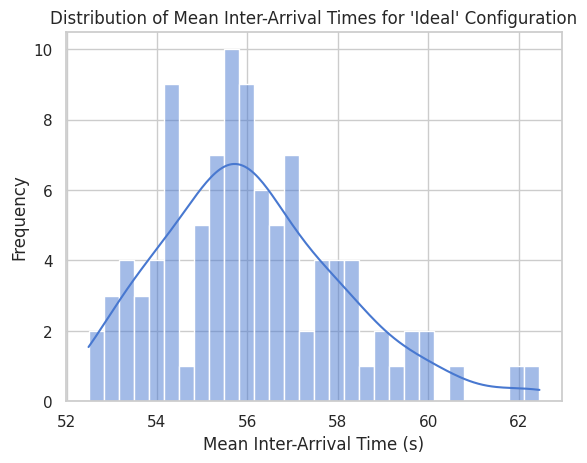

In [63]:
ideal_results = results[results["configuration"] == "ideal"]
# ideal_results = results
print(f"Number of results for 'ideal' configuration: {len(results)}")

sns.histplot(data=ideal_results, x="mean_interarrival", bins=30, kde=True)
plt.xlabel("Mean Inter-Arrival Time (s)")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Inter-Arrival Times for 'Ideal' Configuration")
plt.show()

In [52]:
results

,configuration,seed,mean_interarrival,true_mean_interarrival,pdr,latency,par_changes
0,ideal,12345,59.986209,60.0,0.923077,0.008637,/home/simone/uni/spe/SPE-project/results/batch...
1,ideal,12345_antithetic,54.289619,60.0,0.952381,0.008979,/home/simone/uni/spe/SPE-project/results/batch...
2,ideal,12346,53.066403,60.0,0.951827,0.009363,/home/simone/uni/spe/SPE-project/results/batch...
3,ideal,12346_antithetic,62.459145,60.0,0.924901,0.009357,/home/simone/uni/spe/SPE-project/results/batch...
4,ideal,12347,57.775183,60.0,0.920145,0.008405,/home/simone/uni/spe/SPE-project/results/batch...
...,...,...,...,...,...,...,...
595,unstable,12392_antithetic,67.231598,60.0,0.175824,0.009655,/home/simone/uni/spe/SPE-project/results/batch...
596,unstable,12393,42.943760,60.0,0.103448,0.017625,/home/simone/uni/spe/SPE-project/results/batch...
597,unstable,12393_antithetic,72.684595,60.0,0.182320,0.018606,/home/simone/uni/spe/SPE-project/results/batch...
598,unstable,12394,58.450991,60.0,0.350515,0.016621,/home/simone/uni/spe/SPE-project/results/batch...


## Main Analysis Batch 20251121_23-09-00


### Path configuration


In [53]:
# Path configuration
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20251121_23-09-00").resolve()
TOPOLOGY_FOLDER_TO_ANALYZE = "random_20N"